In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [13]:
application = pd.read_csv("../data/application_train.csv")
bureau = pd.read_csv("../data/bureau.csv")
previous = pd.read_csv("../data/previous_application.csv")
installments = pd.read_csv("../data/installments_payments.csv")

In [14]:
print("Application shape:", application.shape)
print("Bureau shape:", bureau.shape)
print("Previous application shape:", previous.shape)
print("Installments shape:", installments.shape)

print("\nTarget distribution:")
print(application["TARGET"].value_counts(normalize=True) * 100)

Application shape: (307511, 122)
Bureau shape: (1716428, 17)
Previous application shape: (1670214, 37)
Installments shape: (13605401, 8)

Target distribution:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [15]:
def missing_value_report(df, name):
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_report = missing_percent[missing_percent > 0].sort_values(ascending=False)
    
    print(f"\nMissing value report for {name}:")
    print(missing_report.head(20))
    
    return missing_report


application_missing = missing_value_report(application, "application")
bureau_missing = missing_value_report(bureau, "bureau")
previous_missing = missing_value_report(previous, "previous_application")
installments_missing = missing_value_report(installments, "installments_payments")


Missing value report for application:
COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64

Missing value report for bureau:
AMT_ANNUITY               71.473490
AMT_CREDIT_MAX_OVERDUE    65.513264
DAYS_ENDDATE_FACT         36.916958
AMT_CREDIT_SUM_LIMIT      34.477415
AMT_CRED

In [16]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "SK_ID_BUREAU": "count",
    "DAYS_CREDIT": "mean",
    "CREDIT_DAY_OVERDUE": "max",
    "AMT_CREDIT_SUM": "sum",
    "AMT_CREDIT_SUM_DEBT": "sum",
    "AMT_CREDIT_SUM_OVERDUE": "sum"
}).reset_index()

bureau_agg.columns = [
    "SK_ID_CURR",
    "BUREAU_LOAN_COUNT",
    "AVG_DAYS_CREDIT",
    "MAX_CREDIT_OVERDUE_DAYS",
    "TOTAL_BUREAU_CREDIT",
    "TOTAL_BUREAU_DEBT",
    "TOTAL_BUREAU_OVERDUE"
]

In [17]:
previous_agg = previous.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "count",
    "AMT_APPLICATION": "mean",
    "AMT_CREDIT": "mean",
    "AMT_ANNUITY": "mean"
}).reset_index()

previous_agg.columns = [
    "SK_ID_CURR",
    "PREVIOUS_APPLICATION_COUNT",
    "AVG_PREVIOUS_APPLICATION_AMOUNT",
    "AVG_PREVIOUS_CREDIT_AMOUNT",
    "AVG_PREVIOUS_ANNUITY"
]


In [18]:
installments["PAYMENT_DELAY"] = (
    installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
)

installments["LATE_PAYMENT_FLAG"] = np.where(
    installments["PAYMENT_DELAY"] > 0,
    1,
    0
)
installments_agg = installments.groupby("SK_ID_CURR").agg({
    "PAYMENT_DELAY": ["mean", "max"],
    "LATE_PAYMENT_FLAG": "sum",
    "AMT_INSTALMENT": "sum",
    "AMT_PAYMENT": "sum"
}).reset_index()

installments_agg.columns = [
    "SK_ID_CURR",
    "AVG_PAYMENT_DELAY",
    "MAX_PAYMENT_DELAY",
    "TOTAL_LATE_PAYMENTS",
    "TOTAL_INSTALMENT_AMOUNT",
    "TOTAL_PAYMENT_AMOUNT"
]

In [19]:
df = application.merge(bureau_agg, on="SK_ID_CURR", how="left")
df = df.merge(previous_agg, on="SK_ID_CURR", how="left")
df = df.merge(installments_agg, on="SK_ID_CURR", how="left")

print("Final merged dataframe shape:", df.shape)



Final merged dataframe shape: (307511, 137)


In [20]:
important_missing_cols = [
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "TOTAL_BUREAU_DEBT",
    "AVG_PAYMENT_DELAY",
    "TOTAL_LATE_PAYMENTS"
]

for col in important_missing_cols:
    df[col + "_MISSING_FLAG"] = df[col].isnull().astype(int)

In [21]:
df["CREDIT_TO_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

df["ANNUITY_TO_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

df["BUREAU_DEBT_TO_INCOME_RATIO"] = (
    df["TOTAL_BUREAU_DEBT"] / df["AMT_INCOME_TOTAL"]
)

df["PAYMENT_COMPLETION_RATIO"] = (
    df["TOTAL_PAYMENT_AMOUNT"] / df["TOTAL_INSTALMENT_AMOUNT"]
)

df["AGE_YEARS"] = abs(df["DAYS_BIRTH"]) / 365

df["EMPLOYMENT_YEARS"] = abs(df["DAYS_EMPLOYED"]) / 365


# Replace infinite values caused by division problems
df = df.replace([np.inf, -np.inf], np.nan)

In [22]:
features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",

    "BUREAU_LOAN_COUNT",
    "AVG_DAYS_CREDIT",
    "MAX_CREDIT_OVERDUE_DAYS",
    "TOTAL_BUREAU_CREDIT",
    "TOTAL_BUREAU_DEBT",
    "TOTAL_BUREAU_OVERDUE",

    "PREVIOUS_APPLICATION_COUNT",
    "AVG_PREVIOUS_APPLICATION_AMOUNT",
    "AVG_PREVIOUS_CREDIT_AMOUNT",
    "AVG_PREVIOUS_ANNUITY",

    "AVG_PAYMENT_DELAY",
    "MAX_PAYMENT_DELAY",
    "TOTAL_LATE_PAYMENTS",
    "TOTAL_INSTALMENT_AMOUNT",
    "TOTAL_PAYMENT_AMOUNT",

    "CREDIT_TO_INCOME_RATIO",
    "ANNUITY_TO_INCOME_RATIO",
    "BUREAU_DEBT_TO_INCOME_RATIO",
    "PAYMENT_COMPLETION_RATIO",

    "EXT_SOURCE_2_MISSING_FLAG",
    "EXT_SOURCE_3_MISSING_FLAG",
    "TOTAL_BUREAU_DEBT_MISSING_FLAG",
    "AVG_PAYMENT_DELAY_MISSING_FLAG",
    "TOTAL_LATE_PAYMENTS_MISSING_FLAG"
]

target = "TARGET"

X = df[features]
y = df[target]


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [24]:
model_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [25]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [26]:

y_pred = model_pipeline.predict(X_test)

y_prob = model_pipeline.predict_proba(X_test)[:, 1]

In [34]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC Score: 0.7257914923727473

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.68      0.79     56538
           1       0.15      0.66      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.55      0.67      0.52     61503
weighted avg       0.89      0.67      0.75     61503


Confusion Matrix:
[[38189 18349]
 [ 1680  3285]]


In [29]:
results["Risk_Band"] = pd.cut(
    results["Predicted_Default_Probability"],
    bins=[0, 0.05, 0.10, 0.20, 1],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Very High Risk"
    ]
)

In [30]:
results["Decision"] = np.where(
    results["Predicted_Default_Probability"] < 0.10,
    "Approve",
    "Reject"
)

In [31]:
LGD = 0.45

results["EAD_Assumption"] = X_test["AMT_CREDIT"].values

results["Expected_Loss"] = (
    results["Predicted_Default_Probability"]
    * LGD
    * results["EAD_Assumption"]
)


In [32]:
approval_summary = results.groupby("Decision").agg({
    "Predicted_Default_Probability": "mean",
    "Expected_Loss": "sum",
    "Actual_Default": "mean"
}).reset_index()

approval_summary.columns = [
    "Decision",
    "Average_PD",
    "Total_Expected_Loss",
    "Actual_Default_Rate"
]

print("\nApproval Strategy Summary:")
print(approval_summary)



Approval Strategy Summary:
  Decision  Average_PD  Total_Expected_Loss  Actual_Default_Rate
0  Approve    0.080438         1.051341e+07             0.013055
1   Reject    0.436713         6.930188e+09             0.081152


In [45]:
risk_band_summary = results.groupby("Risk_Band").agg({
    "Predicted_Default_Probability": "mean",
    "Expected_Loss": "sum",
    "Actual_Default": "mean"
}).reset_index()

risk_band_summary.columns = [
    "Risk_Band",
    "Average_PD",
    "Total_Expected_Loss",
    "Actual_Default_Rate"
]

print("\nRisk Band Summary:")
print(risk_band_summary)


Risk Band Summary:
        Risk_Band  Average_PD  Total_Expected_Loss  Actual_Default_Rate
0        Low Risk    0.033138         3.286082e+05             0.000000
1     Medium Risk    0.083181         1.018480e+07             0.013812
2       High Risk    0.161423         2.637670e+08             0.018172
3  Very High Risk    0.463354         6.666421e+09             0.087247


C:\Users\Meet\AppData\Local\Temp\ipykernel_16344\3872783380.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_band_summary = results.groupby("Risk_Band").agg({


In [47]:
results.to_csv("../outputs/credit_risk_predictions.csv", index=False)
approval_summary.to_csv("../outputs/approval_strategy_summary.csv", index=False)
risk_band_summary.to_csv("../outputs/risk_band_summary.csv", index=False)

print("\nFiles saved successfully in outputs folder.")


Files saved successfully in outputs folder.


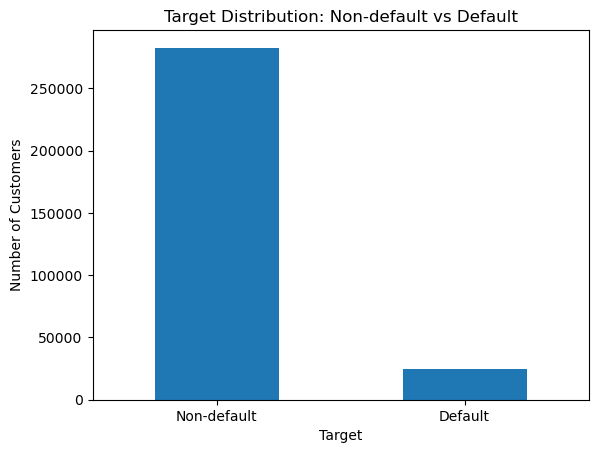

In [36]:
import matplotlib.pyplot as plt

application["TARGET"].value_counts().plot(kind="bar")

plt.title("Target Distribution: Non-default vs Default")
plt.xlabel("Target")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Non-default", "Default"], rotation=0)
plt.show()

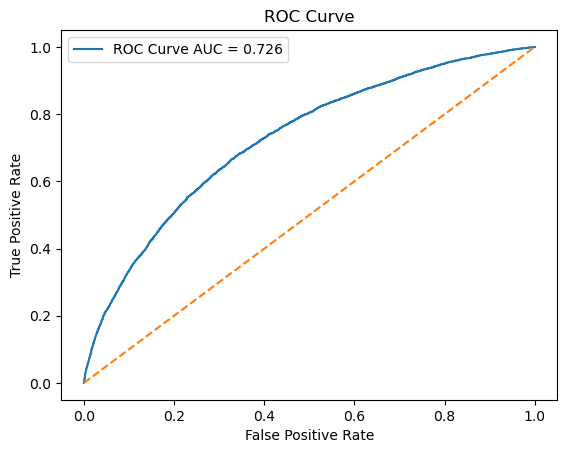

In [37]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC Curve AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

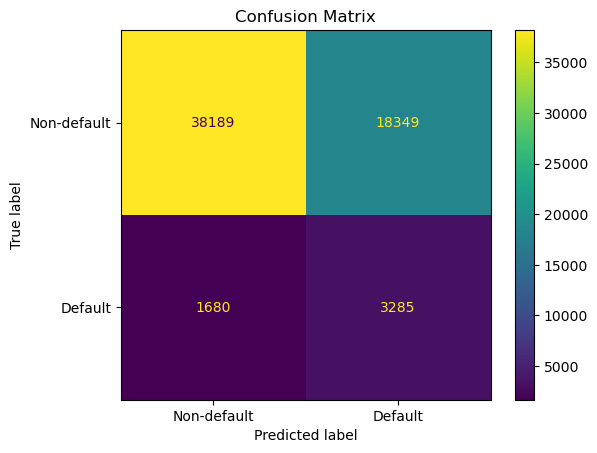

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-default", "Default"]
)

plt.title("Confusion Matrix")
plt.show()

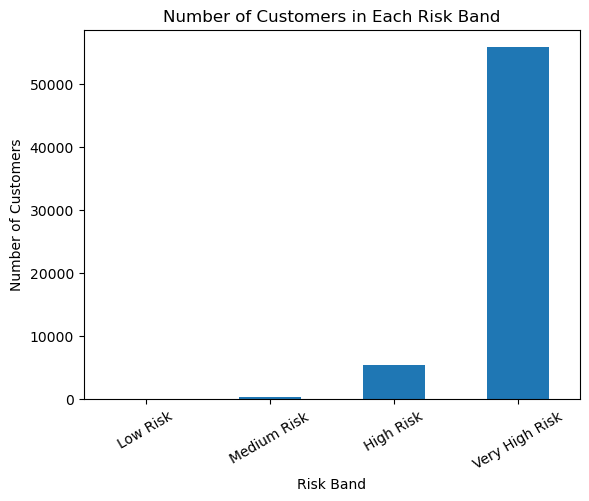

In [39]:
results["Risk_Band"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Customers in Each Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

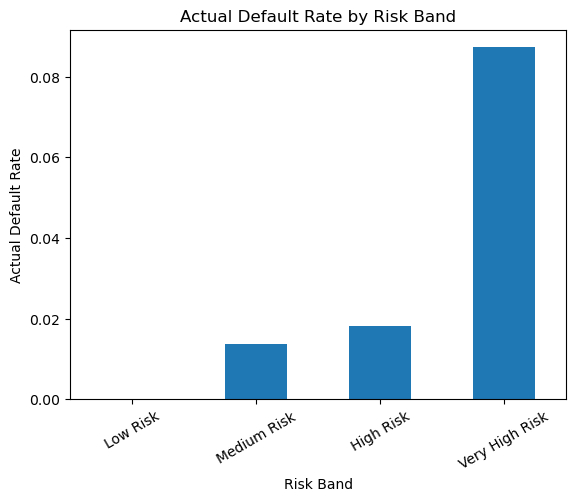

In [40]:
risk_band_summary.plot(
    x="Risk_Band",
    y="Actual_Default_Rate",
    kind="bar",
    legend=False
)

plt.title("Actual Default Rate by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Actual Default Rate")
plt.xticks(rotation=30)
plt.show()

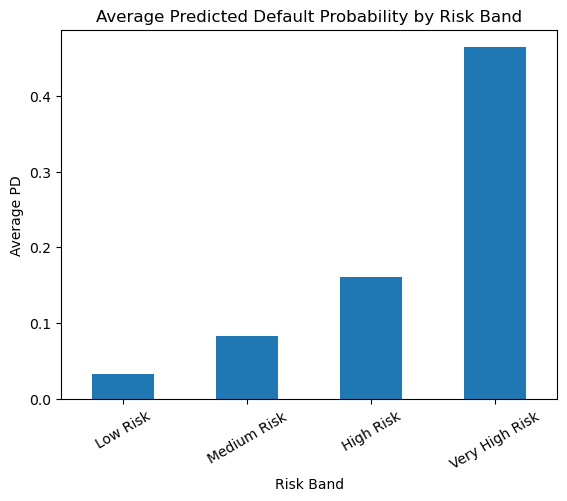

In [41]:
risk_band_summary.plot(
    x="Risk_Band",
    y="Average_PD",
    kind="bar",
    legend=False
)

plt.title("Average Predicted Default Probability by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Average PD")
plt.xticks(rotation=30)
plt.show()

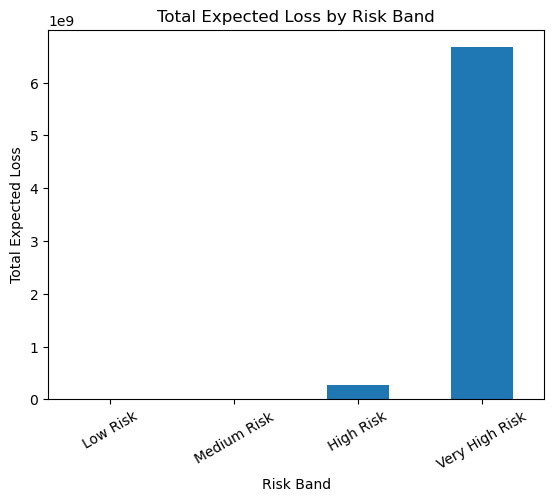

In [42]:
risk_band_summary.plot(
    x="Risk_Band",
    y="Total_Expected_Loss",
    kind="bar",
    legend=False
)

plt.title("Total Expected Loss by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Total Expected Loss")
plt.xticks(rotation=30)
plt.show()

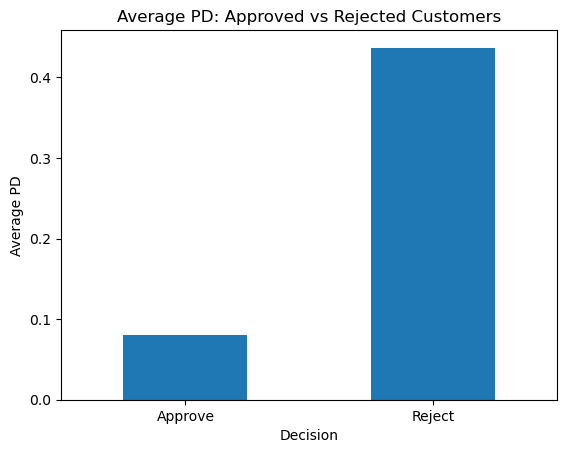

In [43]:
approval_summary.plot(
    x="Decision",
    y="Average_PD",
    kind="bar",
    legend=False
)

plt.title("Average PD: Approved vs Rejected Customers")
plt.xlabel("Decision")
plt.ylabel("Average PD")
plt.xticks(rotation=0)
plt.show()

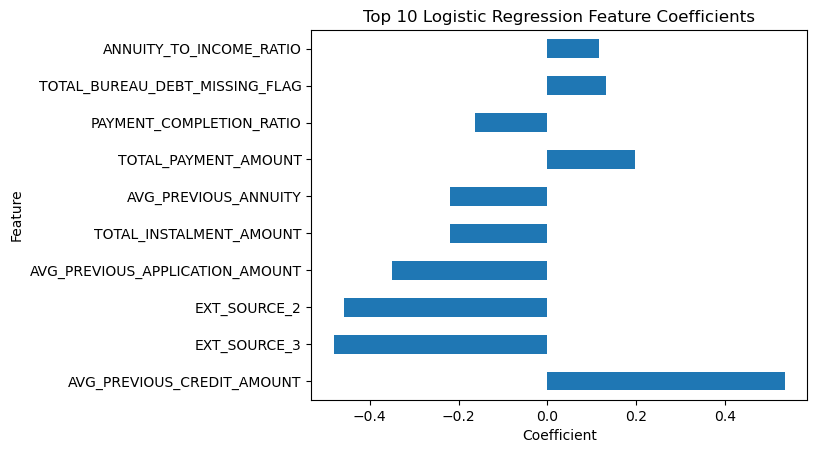

In [44]:
logistic_model = model_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

top_features = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).head(10)

top_features.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False
)

plt.title("Top 10 Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()